# DCG Multiview Refactor - Colab T4 Training Notebook

This notebook is prepared for Google Colab with a T4 GPU.

## What it does
1. Verifies GPU and CUDA.
2. Clones your repository (or uses Google Drive copy).
3. Installs required Python packages.
4. Checks shared dataset files under `datasets/`.
5. Runs training with configurable dataset and epochs.

Set Runtime -> Change runtime type -> GPU before running.

In [1]:
import torch
import subprocess

print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
subprocess.run(['nvidia-smi'])

Torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


CompletedProcess(args=['nvidia-smi'], returncode=0)

In [38]:
# Install gdown if needed
!pip install -q gdown

In [42]:
import os
import gdown
import shutil
import zipfile

BASE_DIR = "/content"

# Download the GitHub project
PROJECT_ROOT = os.path.join(BASE_DIR, "Diffusion-based-approaches")
ZIP_PATH = os.path.join(BASE_DIR, "repo.zip")
EXTRACTED_FOLDER = os.path.join(BASE_DIR, "Diffusion-based-approaches-for-IMVC-main")
DCG_SRC = os.path.join(EXTRACTED_FOLDER, "DCG (NEW)")
DCG_DIR = os.path.join(PROJECT_ROOT, "DCG (NEW)")

os.makedirs(PROJECT_ROOT, exist_ok=True)

# Download ZIP from GitHub
subprocess.run([
    "wget", "-q", "-O", ZIP_PATH,
    "https://github.com/EddarirOmar/Diffusion-based-approaches-for-IMVC/archive/refs/heads/main.zip"
], check=True)

# Extract ZIP
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(BASE_DIR)

# Remove old DCG folder if exists
shutil.rmtree(DCG_DIR, ignore_errors=True)

# Move DCG folder to project root
shutil.move(DCG_SRC, PROJECT_ROOT)

print("Project downloaded to:", PROJECT_ROOT)
print("DCG path:", DCG_DIR)

Project downloaded to: /content/Diffusion-based-approaches (1)
DCG path: /content/Diffusion-based-approaches (1)/DCG (NEW)


In [50]:
# Download datasets
DATASETS_DIR = os.path.join(PROJECT_ROOT, "datasets")
os.makedirs(DATASETS_DIR, exist_ok=True)

# Dataset name → (Google Drive link, desired filename)
DATASET_FILES = {
    "Synthetic3d": ("https://drive.google.com/file/d/1sCgWYojsHjLqgEkijiD5XfreCIYw3APP/view?usp=sharing", "Synthetic3d.mat"),
    "Scene-15": ("https://drive.google.com/file/d/1ENVvuQPFNceR6zhS-c53Qg4qCoFi6sFQ/view?usp=sharing", "Scene-15.mat"),
    "NoisyMNIST": ("https://drive.google.com/file/d/1jLgApO9_RvoIb96nzIgiq2nv8T1WjCbi/view?usp=sharing", "NoisyMNIST.mat"),
    "LandUse-21": ("https://drive.google.com/file/d/19J6kxTYAvRHuCBrA7suPgc0Oe--C38e2/view?usp=sharing", "LandUse-21.mat"),
    "Handwritten": ("https://drive.google.com/file/d/17OpkAo5_TTIjmE4FfB00WPXMkZlVSpb9/view?usp=sharing", "Handwritten.mat"),
    "CUB": ("https://drive.google.com/file/d/1T1ndPETHyenoBGFhVAQZbJUL725XK9G0/view?usp=sharing", "CUB.mat"),
}

def download_datasets(dataset_files, dest_dir=DATASETS_DIR):
    os.makedirs(dest_dir, exist_ok=True)

    for name, (link, filename) in dataset_files.items():
        print(f"\nDownloading {name} ...")
        output_path = os.path.join(dest_dir, filename)

        # Extract file ID from Google Drive link
        file_id = link.split("/d/")[1].split("/")[0]
        gdown.download(f"https://drive.google.com/uc?id={file_id}", output_path, quiet=False)
        print(f"{name} ready at {output_path}")

# Run the download
download_datasets(DATASET_FILES)
print("\nAll datasets ready in:", DATASETS_DIR)

Downloading...
From (original): https://drive.google.com/uc?id=1sCgWYojsHjLqgEkijiD5XfreCIYw3APP
From (redirected): https://drive.google.com/uc?id=1sCgWYojsHjLqgEkijiD5XfreCIYw3APP&confirm=t&uuid=28567b5a-9395-4055-82d5-2a95b0bf9012
To: /content/Diffusion-based-approaches/datasets/Synthetic3d.mat
100%|██████████| 53.8k/53.8k [00:00<00:00, 33.7MB/s]


Synthetic3d ready at /content/Diffusion-based-approaches/datasets/Synthetic3d.mat



Downloading...
From (original): https://drive.google.com/uc?id=1ENVvuQPFNceR6zhS-c53Qg4qCoFi6sFQ
From (redirected): https://drive.google.com/uc?id=1ENVvuQPFNceR6zhS-c53Qg4qCoFi6sFQ&confirm=t&uuid=ef066aff-90e1-4de9-baef-e8dcc61cd38f
To: /content/Diffusion-based-approaches/datasets/Scene-15.mat
100%|██████████| 3.38M/3.38M [00:00<00:00, 197MB/s]


Scene-15 ready at /content/Diffusion-based-approaches/datasets/Scene-15.mat



Downloading...
From (original): https://drive.google.com/uc?id=1jLgApO9_RvoIb96nzIgiq2nv8T1WjCbi
From (redirected): https://drive.google.com/uc?id=1jLgApO9_RvoIb96nzIgiq2nv8T1WjCbi&confirm=t&uuid=bfd67726-fee5-4f9d-a709-8fdbcbe6e550
To: /content/Diffusion-based-approaches/datasets/NoisyMNIST.mat
100%|██████████| 480M/480M [00:04<00:00, 96.4MB/s]


...

LandUse-21 ready at /content/Diffusion-based-approaches/datasets/LandUse-21.mat



Downloading...
From (original): https://drive.google.com/uc?id=17OpkAo5_TTIjmE4FfB00WPXMkZlVSpb9
From (redirected): https://drive.google.com/uc?id=17OpkAo5_TTIjmE4FfB00WPXMkZlVSpb9&confirm=t&uuid=3fadf750-3818-48a4-b0e9-a1b293beb0e6
To: /content/Diffusion-based-approaches/datasets/Handwritten.mat
100%|██████████| 3.48M/3.48M [00:00<00:00, 168MB/s]


Handwritten ready at /content/Diffusion-based-approaches/datasets/Handwritten.mat



Downloading...
From (original): https://drive.google.com/uc?id=1T1ndPETHyenoBGFhVAQZbJUL725XK9G0
From (redirected): https://drive.google.com/uc?id=1T1ndPETHyenoBGFhVAQZbJUL725XK9G0&confirm=t&uuid=d83b877e-b226-490e-9969-76c5dbedbea0
To: /content/Diffusion-based-approaches/datasets/CUB.mat
100%|██████████| 3.18M/3.18M [00:00<00:00, 240MB/s]

CUB ready at /content/Diffusion-based-approaches/datasets/CUB.mat

All datasets ready in: /content/Diffusion-based-approaches/datasets


In [4]:
# Install required dependencies for this project
%pip install -q numpy scipy scikit-learn munkres

In [53]:
# Quick dataset presence check (shared datasets folder)
import os

data_dir = DATASETS_DIR
required = [
    'Handwritten.mat',
    'CUB.mat',
]


print('Data dir:', data_dir)
for f in required:
    p = os.path.join(data_dir, f)
    print(f, '->', 'FOUND' if os.path.exists(p) else 'MISSING')

Data dir: /content/Diffusion-based-approaches/datasets
Handwritten.mat -> FOUND
CUB.mat -> FOUND


In [12]:
# Optional quick sanity check
%cd {DCG_DIR}
!python smoke_test.py --dataset synthetic3d

/content/Diffusion-based-approaches/DCG (NEW)
shuffle
Epoch: 0/2 ==> loss = 6.3767 | rec=2.2702 df=1.9083 ce=2.0366 mmi=-0.0000 clu=1.5988 hc=0.0171
Epoch: 1/2 ==> loss = 3.6882 | rec=0.3913 df=1.4726 ce=1.6704 mmi=-0.0000 clu=1.5062 hc=0.0330
Epoch: 2/2 ==> loss = 3.1206 | rec=0.2956 df=1.1448 ce=1.5223 mmi=-0.0000 clu=1.5390 hc=0.0397
SMOKE_RESULT ACC=0.7467 NMI=0.4560 ARI=0.4551


## Lambda Tuning (Optuna)

Run this section to search for the best `lambda_*` values before your full training run.

Notes:
- Start with `Synthetic3d` for quick iteration.
- Increase `N_TRIALS` and `TUNE_EPOCHS` for stronger results.
- The objective is mean of `(ACC + NMI + ARI) / 3`.

In [7]:
%pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 29.0 MB/s eta 0:00:00


In [13]:
import os
import json
import random
import itertools
from datetime import datetime

import numpy as np
import torch
import optuna
import pandas as pd

from configure import get_default_config
from datasets import load_data
from get_indicator_matrix_A import get_mask
from ICDM import icdm

# Tuning controls
TUNE_DATASET = 'CUB'   # e.g. Synthetic3d, CUB, HandWritten, Multi-Fashion, LandUse_21
TUNE_MISSING_RATE = 0.1
TUNE_EPOCHS = 30
N_TRIALS = 20
SEED = 42

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Tuning device:', DEVICE)


def build_optimizer(model, lr):
    ae_params = itertools.chain.from_iterable(ae.parameters() for ae in model.autoencoders)
    df_params = itertools.chain.from_iterable(df.parameters() for df in model.dfs)
    return torch.optim.Adam(
        itertools.chain(ae_params, df_params, model.clusterLayer.parameters(), model.AttentionLayer.parameters()),
        lr=lr,
    )


def prepare_inputs(x_list, missing_rate, device):
    n_views = len(x_list)
    n_samples = x_list[0].shape[0]
    mask = get_mask(n_views, n_samples, missing_rate)

    x_train_list = []
    for v in range(n_views):
        x_masked = x_list[v] * mask[:, v][:, np.newaxis]
        x_train_list.append(torch.from_numpy(x_masked).float().to(device))

    return x_train_list, torch.from_numpy(mask).long().to(device)


def objective(trial):
    config = get_default_config(TUNE_DATASET)
    config['dataset'] = TUNE_DATASET
    config['training']['epoch'] = TUNE_EPOCHS
    config['print_num'] = max(1, TUNE_EPOCHS)
    config['training']['missing_rate'] = TUNE_MISSING_RATE

    # Search space for lambda_* and MMI calibration knobs
    config['training']['lambda_rec'] = trial.suggest_float('lambda_rec', 1e-2, 1e1, log=True)
    config['training']['lambda_df'] = trial.suggest_float('lambda_df', 1e-2, 1e1, log=True)
    config['training']['lambda_ce'] = trial.suggest_float('lambda_ce', 1e-2, 1e1, log=True)
    config['training']['lambda_mmi'] = trial.suggest_float('lambda_mmi', 1e-4, 1.0, log=True)
    config['training']['lambda_cluster'] = trial.suggest_float('lambda_cluster', 1e-3, 1.0, log=True)
    config['training']['lambda_hc'] = trial.suggest_float('lambda_hc', 1e-3, 1.0, log=True)
    config['training']['mmi_temperature'] = trial.suggest_float('mmi_temperature', 0.05, 1.0, log=True)
    config['training']['mmi_internal_lambda'] = trial.suggest_float('mmi_internal_lambda', 0.1, 2.0)

    # Keep seeds deterministic trial-to-trial
    run_seed = SEED + trial.number
    random.seed(run_seed)
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(run_seed)

    x_list, y_list = load_data(config)
    x_train_list, mask = prepare_inputs(x_list, config['training']['missing_rate'], DEVICE)

    model = icdm(config)
    model.to_device(DEVICE)
    optimizer = build_optimizer(model, config['training']['lr'])

    acc, nmi, ari = model.train(config, x_train_list, y_list, mask, optimizer, DEVICE)
    score = float((acc + nmi + ari) / 3.0)

    trial.set_user_attr('acc', float(acc))
    trial.set_user_attr('nmi', float(nmi))
    trial.set_user_attr('ari', float(ari))
    return score


study = optuna.create_study(direction='maximize', study_name='dcg_lambda_tuning')
study.optimize(objective, n_trials=N_TRIALS)

print('Best score:', study.best_value)
print('Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

safe_dataset = TUNE_DATASET.replace(' ', '_').replace('-', '_')
safe_mr = str(TUNE_MISSING_RATE).replace('.', 'p')
best_filename = f'best_lambda_{safe_dataset}_mr{safe_mr}.json'
best_path = os.path.join(DCG_DIR, best_filename)
legacy_best_path = os.path.join(DCG_DIR, 'best_lambda_params.json')

payload = {
    'dataset': TUNE_DATASET,
    'missing_rate': TUNE_MISSING_RATE,
    'tune_epochs': TUNE_EPOCHS,
    'n_trials': N_TRIALS,
    'best_score': study.best_value,
    'best_params': study.best_params,
    'best_metrics': {
        'acc': study.best_trial.user_attrs.get('acc'),
        'nmi': study.best_trial.user_attrs.get('nmi'),
        'ari': study.best_trial.user_attrs.get('ari'),
    },
}

# Primary per-dataset file
with open(best_path, 'w', encoding='utf-8') as f:
    json.dump(payload, f, indent=2)

# Backward-compat convenience file
with open(legacy_best_path, 'w', encoding='utf-8') as f:
    json.dump(payload, f, indent=2)

# Append summary row
summary_path = os.path.join(DCG_DIR, 'lambda_tuning_summary.csv')
row = {
    'timestamp': datetime.utcnow().isoformat(),
    'dataset': TUNE_DATASET,
    'missing_rate': TUNE_MISSING_RATE,
    'tune_epochs': TUNE_EPOCHS,
    'n_trials': N_TRIALS,
    'best_score': study.best_value,
    'acc': payload['best_metrics']['acc'],
    'nmi': payload['best_metrics']['nmi'],
    'ari': payload['best_metrics']['ari'],
    'best_filename': best_filename,
}
for k, v in study.best_params.items():
    row[k] = v

if os.path.exists(summary_path):
    df = pd.read_csv(summary_path)
    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
else:
    df = pd.DataFrame([row])

df.to_csv(summary_path, index=False)

print('Saved dataset-specific params:', best_path)
print('Updated legacy params file:', legacy_best_path)
print('Updated tuning summary:', summary_path)

### Use tuned lambdas in final training

After tuning, load `best_lambda_params.json` and apply the best values in your training config (or pass them into `run.py` once we expose lambda CLI flags).

In [14]:
import json

# Must match your intended training target
TARGET_DATASET = 'CUB'
TARGET_MISSING_RATE = 0.3

safe_dataset = TARGET_DATASET.replace(' ', '_').replace('-', '_')
safe_mr = str(TARGET_MISSING_RATE).replace('.', 'p')
best_filename = f'best_lambda_{safe_dataset}_mr{safe_mr}.json'
best_path = os.path.join(DCG_DIR, best_filename)

with open(best_path, 'r', encoding='utf-8') as f:
    best = json.load(f)

assert best['dataset'] == TARGET_DATASET, f"Dataset mismatch: expected {TARGET_DATASET}, found {best['dataset']}"
assert float(best['missing_rate']) == float(TARGET_MISSING_RATE), (
    f"Missing-rate mismatch: expected {TARGET_MISSING_RATE}, found {best['missing_rate']}"
)

print('Best tuned params loaded from:', best_path)
for k, v in best['best_params'].items():
    print(f'{k}: {v}')

Best tuned params loaded from: /content/Diffusion-based-approaches/DCG (NEW)/best_lambda_CUB_mr0p3.json
lambda_rec: 0.016763017695680008
lambda_df: 0.012019772763377443
lambda_ce: 0.011260786597807037
lambda_mmi: 0.004143066788712666
lambda_cluster: 0.7907078058336803
lambda_hc: 0.30394086062856396
mmi_temperature: 0.050753412249944105
mmi_internal_lambda: 1.9602313704350798


## Final Training

Run this after the tuning cells if you want to use tuned lambda values.

In [32]:
# Training runner for run.py

import os
import shlex
import subprocess

# Dataset IDs in run.py:
# 1: LandUse_21, 2: CUB, 3: HandWritten, 4: Multi-Fashion, 5: Synthetic3d
DATASET_ID = 2
EPOCHS = 20
TEST_TIME = 2
GPU_DEVICE = '0'

# You can pass one rate ('0.1') or many ('0.1,0.3,0.5')
TRAIN_MISSING_RATES = '0.3'

# Lambda mode: 'auto' | 'manual' | 'none'
LAMBDA_MODE = 'auto'

# Used only when LAMBDA_MODE='manual'
MANUAL_LAMBDA_CONFIG = ''

# Runtime behavior
CHECKPOINT_DIR = 'checkpoints'
RESUME_CHECKPOINT = ''
# RESUME_CHECKPOINT = "checkpoints/CUB_mr0p3_seed1_last.pt"
SAVE_CHECKPOINT = True
SAVE_METRICS = True


DATASET_ID_TO_NAME = {
    1: 'LandUse_21',
    2: 'CUB',
    3: 'HandWritten',
    4: 'Multi-Fashion',
    5: 'Synthetic3d',
}

dataset_name = DATASET_ID_TO_NAME[DATASET_ID]
first_mr = float(str(TRAIN_MISSING_RATES).split(',')[0].strip())
safe_dataset = dataset_name.replace(' ', '_').replace('-', '_')
safe_mr = str(first_mr).replace('.', 'p')
auto_lambda = f'best_lambda_{safe_dataset}_mr{safe_mr}.json'

if LAMBDA_MODE == 'auto':
    lambda_config = auto_lambda if os.path.exists(auto_lambda) else ''
elif LAMBDA_MODE == 'manual':
    lambda_config = MANUAL_LAMBDA_CONFIG
else:
    lambda_config = ''

cmd = f"python run.py --dataset {DATASET_ID} --epoch {EPOCHS} --test_time {TEST_TIME} --devices {GPU_DEVICE} --missing_rate {TRAIN_MISSING_RATES} --checkpoint_dir {CHECKPOINT_DIR}"

if lambda_config:
    cmd += f" --lambda_config {lambda_config}"
if RESUME_CHECKPOINT:
    cmd += f" --resume_checkpoint {RESUME_CHECKPOINT}"
if not SAVE_CHECKPOINT:
    cmd += " --no_checkpoint"
if not SAVE_METRICS:
    cmd += " --no_metrics"

# Change directory inside the notebook
%cd "{DCG_DIR}"

# Run the command
!{cmd}

/content/Diffusion-based-approaches/DCG (NEW)
GPU: True
Applied tuned params from best_lambda_CUB_mr0p3.json
  lambda_ce: 0.011260786597807037
  lambda_cluster: 0.7907078058336803
  lambda_df: 0.012019772763377443
  lambda_hc: 0.30394086062856396
  lambda_mmi: 0.004143066788712666
  lambda_rec: 0.016763017695680008
  mmi_internal_lambda: 1.9602313704350798
  mmi_temperature: 0.050753412249944105
Data set: CUB
Checkpoint dir: /content/Diffusion-based-approaches/DCG (NEW)/checkpoints
shuffle
--------------------Missing rate = 0.3--------------------
Resumed from checkpoint: checkpoints/CUB_mr0p3_seed1_last.pt
Epoch: 0/20 ==> loss = 1.0856 | rec=0.5580 df=0.1205 ce=5.4716 mmi=-3.9498 clu=1.2988 hc=0.0086
Epoch: 1/20 ==> loss = 1.0776 | rec=0.5663 df=0.1124 ce=5.5087 mmi=-3.9488 clu=1.2881 hc=0.0086
Epoch: 2/20 ==> loss = 1.0773 | rec=0.5574 df=0.1174 ce=5.4945 mmi=-3.9523 clu=1.2881 hc=0.0084
Epoch: 3/20 ==> loss = 1.1054 | rec=0.5552 df=0.1055 ce=5.5099 mmi=-3.9478 clu=1.3235 hc=0.0086
E

## Plot Metrics After Final Training

This section loads per-run metric files saved by `run.py` and plots:
- Training losses per epoch (`loss`, `rec_loss`, `df_loss`, `ce_loss`, `mmi_loss`, `cluster_loss`, `hc_loss`)
- Clustering metrics per epoch (`accuracy`, `NMI`, `ARI`)

It supports multiple seeds (`seed*_metrics.csv`) and shows both individual-seed curves and mean curves.

In [33]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Metrics are saved in run.py under checkpoint_dir (default: DCG_DIR/checkpoints)
METRICS_DIR = os.path.join(DCG_DIR, 'checkpoints')

# Resolve dataset name and missing-rate token using training controls above
dataset_name = DATASET_ID_TO_NAME[DATASET_ID]
safe_mr = str(TARGET_MISSING_RATE).replace('.', 'p')
pattern = os.path.join(METRICS_DIR, f"{dataset_name}_mr{safe_mr}_seed*_metrics.csv")
csv_files = sorted(glob.glob(pattern))

print('Metrics directory:', METRICS_DIR)
print('Found metric CSV files:', len(csv_files))
for p in csv_files:
    print(' -', os.path.basename(p))

if not csv_files:
    raise FileNotFoundError(
        f'No metric CSV found for pattern: {pattern}. '
        'Run final training first (without --no_metrics).'
)

# Load all runs
dfs = []
for p in csv_files:
    df = pd.read_csv(p)
    df['run_file'] = os.path.basename(p)
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

required_cols = [
    'epoch', 'loss', 'rec_loss', 'df_loss', 'ce_loss', 'mmi_loss', 'cluster_loss', 'hc_loss',
    'accuracy', 'NMI', 'ARI',
]
missing_cols = [c for c in required_cols if c not in all_df.columns]
if missing_cols:
    raise ValueError(f'Missing expected metric columns: {missing_cols}')

# Ensure numeric columns are numeric
for c in required_cols:
    all_df[c] = pd.to_numeric(all_df[c], errors='coerce')

# Aggregate mean/std over runs by epoch
agg = all_df.groupby('epoch', as_index=False)[required_cols[1:]].agg(['mean', 'std'])
agg.columns = ['epoch'] + [f"{m}_{s}" for m, s in agg.columns.tolist()[1:]]

def plot_group(metrics, title, y_label):
    n = len(metrics)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), constrained_layout=True)
    if n == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        # Individual runs
        for run_name, run_df in all_df.groupby('run_file'):
            ax.plot(run_df['epoch'], run_df[metric], alpha=0.25, linewidth=1)

        # Mean + std ribbon
        mu = agg[f'{metric}_mean']
        sigma = agg[f'{metric}_std'].fillna(0.0)
        ax.plot(agg['epoch'], mu, linewidth=2.5, label='mean')
        ax.fill_between(agg['epoch'], mu - sigma, mu + sigma, alpha=0.2, label='mean±std')

        ax.set_title(metric)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(y_label)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')

    fig.suptitle(title, fontsize=13)
    plt.show()

loss_metrics = ['loss', 'rec_loss', 'df_loss', 'ce_loss', 'mmi_loss', 'cluster_loss', 'hc_loss']
cluster_metrics = ['accuracy', 'NMI', 'ARI']


Metrics directory: /content/Diffusion-based-approaches/DCG (NEW)/checkpoints
Found metric CSV files: 2
 - CUB_mr0p3_seed1_metrics.csv
 - CUB_mr0p3_seed2_metrics.csv


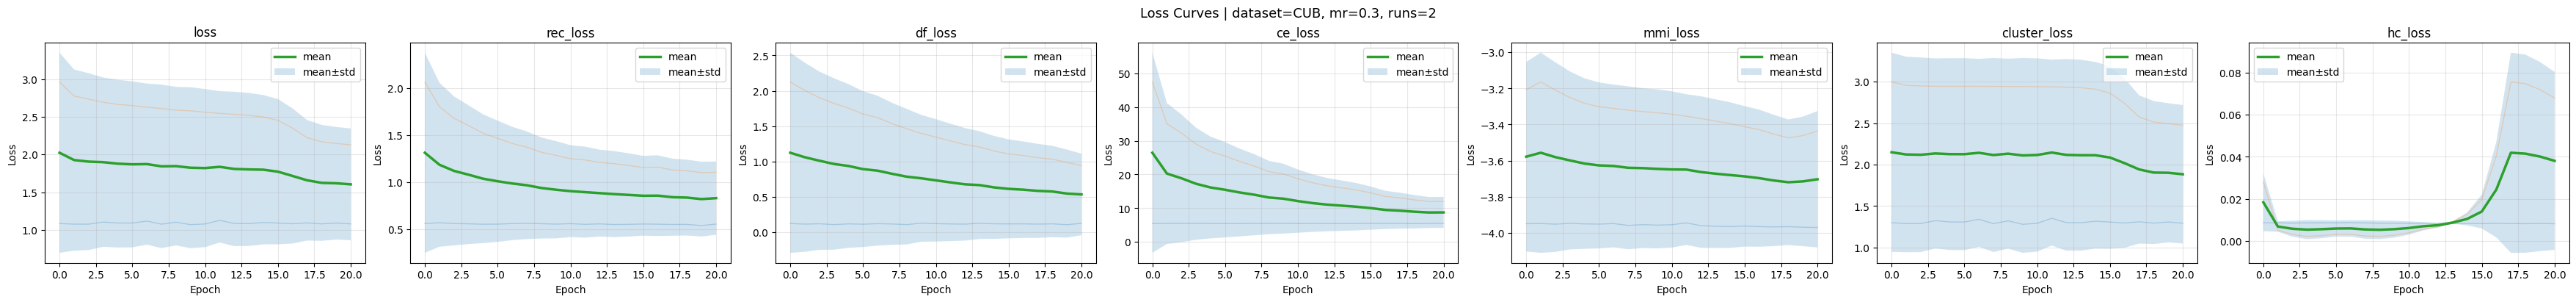

In [34]:
plot_group(
    loss_metrics,
    f'Loss Curves | dataset={dataset_name}, mr={TARGET_MISSING_RATE}, runs={len(csv_files)}',
    'Loss',
)

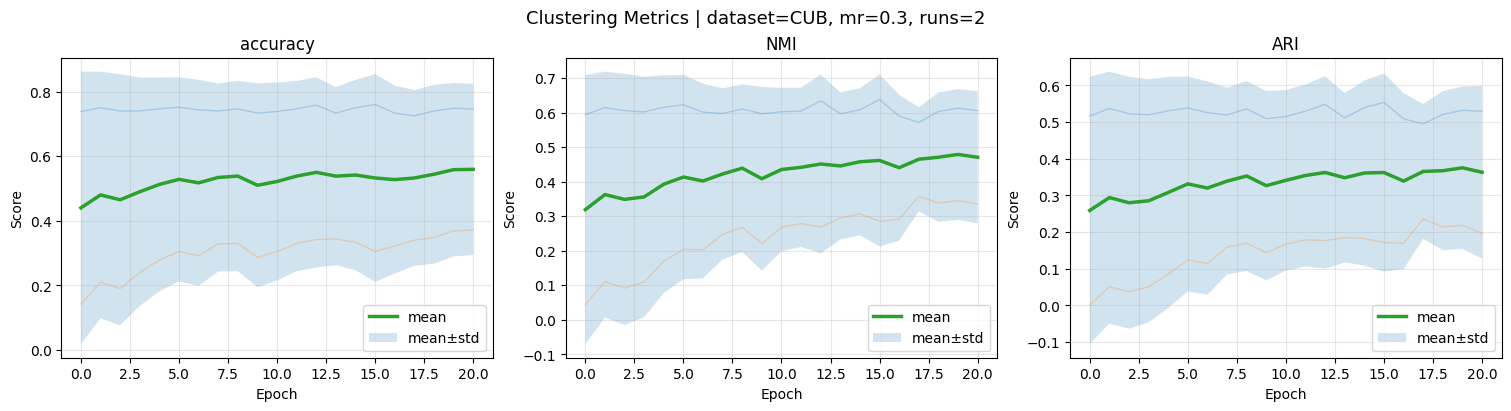

In [55]:
plot_group(
    cluster_metrics,
    f'Clustering Metrics | dataset={dataset_name}, mr={TARGET_MISSING_RATE}, runs={len(csv_files)}',
    'Score',
)

In [54]:
# Optional: show final-epoch summary per run
final_rows = all_df.sort_values('epoch').groupby('run_file', as_index=False).tail(1)
display_cols = ['run_file', 'epoch', 'accuracy', 'NMI', 'ARI', 'loss']
print('\nFinal epoch summary per run:')
display(final_rows[display_cols].sort_values('run_file'))

# Optional: save merged and aggregated tables for external plotting
# merged_out = os.path.join(METRICS_DIR, f"{dataset_name}_mr{safe_mr}_all_runs_metrics.csv")
# agg_out = os.path.join(METRICS_DIR, f"{dataset_name}_mr{safe_mr}_epoch_mean_std_metrics.csv")
# all_df.to_csv(merged_out, index=False)
# agg.to_csv(agg_out, index=False)
# print('\nSaved merged metrics:', merged_out)
# print('Saved epoch mean/std metrics:', agg_out)


Final epoch summary per run:


,run_file,epoch,accuracy,NMI,ARI,loss
20,CUB_mr0p3_seed1_metrics.csv,20,0.7467,0.6056,0.5293,1.080691
41,CUB_mr0p3_seed2_metrics.csv,20,0.3717,0.3353,0.1967,2.128728
